In [1]:
import pandas as pd
import re
from collections import Counter
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pytz

In [2]:
# Read the list of filenames from the configuration file
with open('../file_list.txt', 'r', encoding='utf-8') as config_file:
    file_names = config_file.read().splitlines()

# Regex pattern to match the data format
pattern = r'\[(.*?)\] (.*?): (.*)'

# Initialize an empty list to store parsed data
datalist = []
stream_count = 0
# Iterate over each specified file
for file in file_names:
    full_path = f"../data/{file}"
    with open(full_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            match = re.match(pattern, line)
            if match:
                date, user, message = match.groups()
                datalist.append([date, user, message,stream_count])
    stream_count = stream_count + 1

# Create a DataFrame from the parsed data
data = pd.DataFrame(datalist, columns=["date", "user", "message","stream"])


In [3]:

data['date'] = pd.to_datetime(data['date'])


In [4]:

def convert_utc_to_cet(df, date_column='date'):
    # Make a copy to avoid modifying the original
    df = df.copy()
    
    # Ensure timestamps are UTC aware
    if df[date_column].dt.tz is None:
        df[date_column] = df[date_column].dt.tz_localize('UTC')
    elif df[date_column].dt.tz != pytz.UTC:
        df[date_column] = df[date_column].dt.tz_convert('UTC')
    
    # Convert to CET/CEST (Europe/Berlin includes proper DST handling)
    df[date_column] = df[date_column].dt.tz_convert('Europe/Berlin')
    
    return df

data = convert_utc_to_cet(data)


In [5]:
data["user"] = data["user"].replace("Banties1g", "banties_x")
data["user"] = data["user"].replace("banties1g", "banties_x")
data["user"] = data["user"].replace("chili_poe", "chili_con_bacon")
data["user"] = data["user"].replace("CHILI_POE", "chili_con_bacon")
data["user"] = data["user"].replace("Chili_poe", "chili_con_bacon")
data["user"] = data["user"].replace("chili_conbacon", "chili_con_bacon")
data["user"] = data["user"].replace("Wirelesss_", "W1r3lesss")
data["user"] = data["user"].replace("treklul", "trek44_")
data["user"] = data["user"].replace("ttrek_", "trek44_")
data["user"] = data["user"].replace("trek_x", "trek44_")
data["user"] = data["user"].replace("TriplesingleJ", "TripleSingleJames")
data["user"] = data["user"].replace("uwu_cougar", "uuccugr")
data["user"] = data["user"].replace("uuccugr_","uuccugr")
data["user"] = data["user"].replace("StanIV4_", "stan_iv4")
data["user"] = data["user"].replace("Muuskie2", "Muuskie")
data["user"] = data["user"].replace("nishad_more1311", "nishad13")
data["user"] = data["user"].replace("softarballt", "softarr")
data["user"] = data["user"].replace("softarballtt23", "softarr")
data["user"] = data["user"].replace("lajosbarnabas", "lajoss__")
data["user"] = data["user"].replace("Bonkwiththefunk", "bonk67")
data["user"] = data["user"].replace("qfishyy11", "bonk67")

In [6]:
# Get all unique usernames
unique_users = data['user'].unique()

# Create a mapping from lowercase username to all variants

user_variants = defaultdict(set)
for user in unique_users:
    user_variants[user.lower()].add(user)

# Find usernames with different capitalization
duplicate_users = {k: v for k, v in user_variants.items() if len(v) > 1}

In [7]:
# Create a mapping from all variants to the canonical (sorted first) variant
variant_map = {}
for variants in duplicate_users.values():
    sorted_variants = sorted(variants)
    canonical = sorted_variants[0]
    for v in variants:
        variant_map[v] = canonical

# Replace usernames in 'user' column
data['user'] = data['user'].apply(lambda u: variant_map.get(u, u))

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


Users who started on stream 156 and visited >= 20 other streams:
['CuteKittenMeowMeow', 'fab_odd', 'fcukboii']

Found 2 raid(s) on Stream 156:
                Raid Time       Raider  Viewer Count
2024-11-07 14:42:12+01:00 turpentine__             3
2024-11-07 19:09:35+01:00         gkey           164


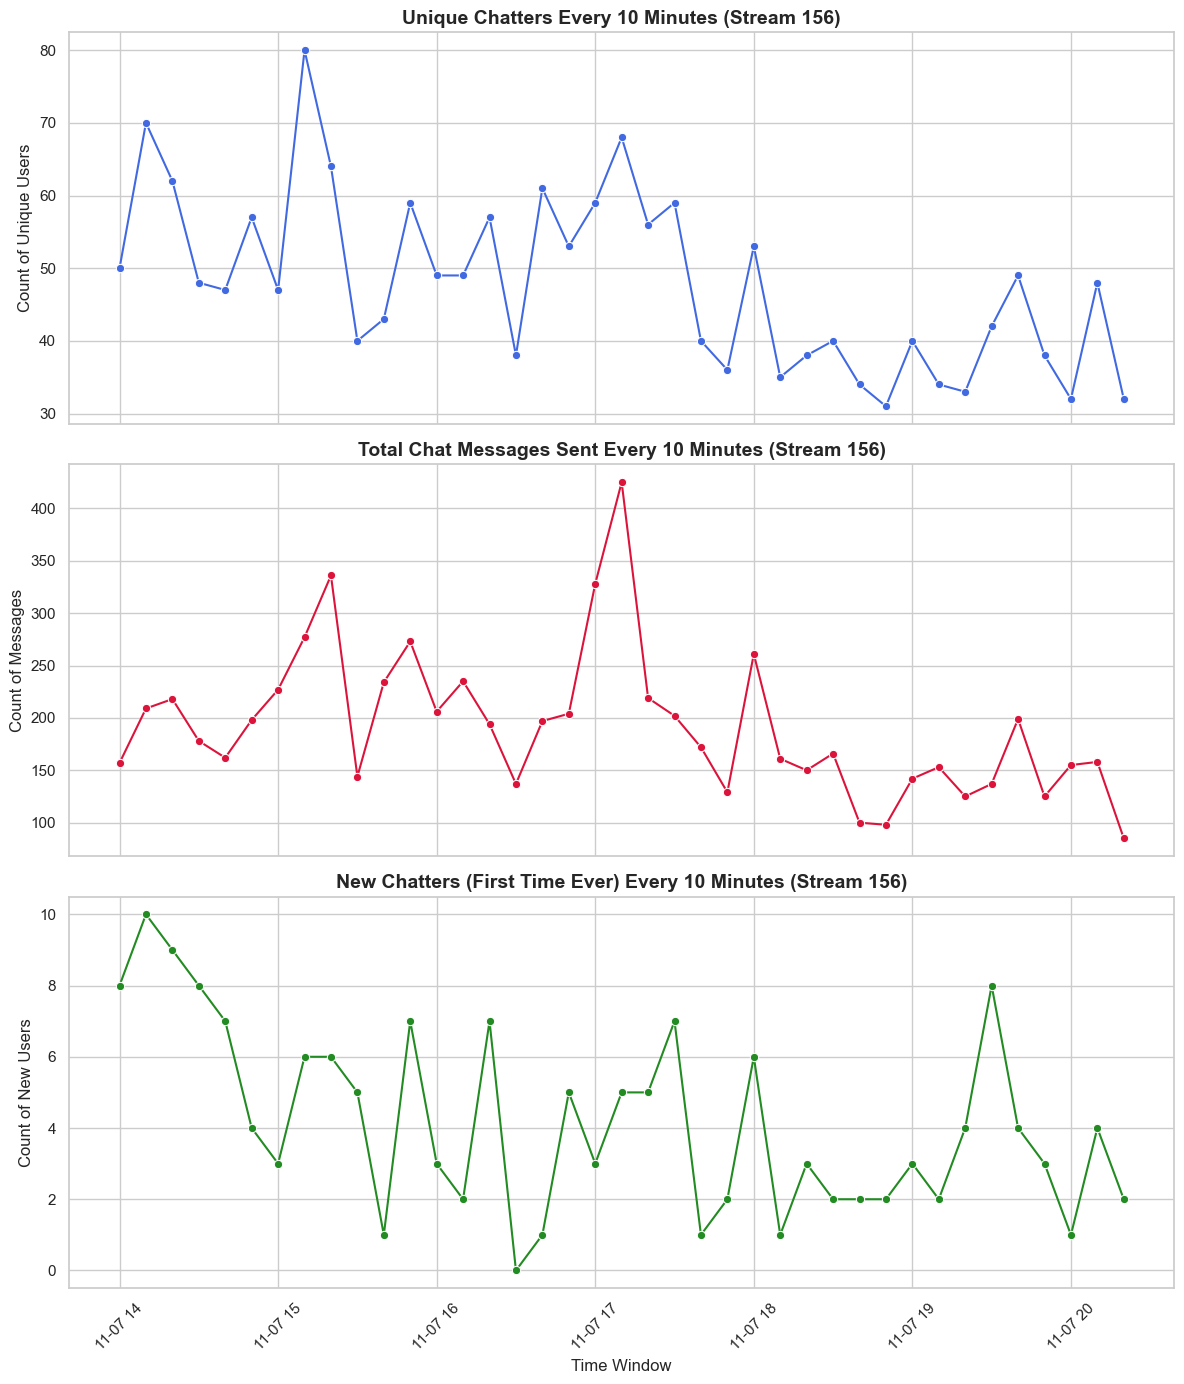

In [12]:

# Set style for nice-looking plots
sns.set_theme(style="whitegrid")

# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Find the absolute first stream each user ever chatted in
# Assumes the data frame is sorted chronologically by 'date'
first_stream_per_user = data.sort_values('date').groupby('user')['stream'].first()

# Users whose VERY FIRST stream was 156
started_on_156 = first_stream_per_user[first_stream_per_user == 156].index

# Count how many unique streams EACH user has participated in overall
total_unique_streams = data.groupby('user')['stream'].nunique()

# Filter total unique streams to ONLY include those who started on 156
# We subtract 1 because we want "20 ANOTHER streams" (excluding 156)
target_users = total_unique_streams.loc[started_on_156]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 156 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 156 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 156
df_156 = data[data['stream'] == 156].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_156['is_new_chatter'] = df_156['user'].isin(started_on_156) & ~df_156['user'].duplicated()

# Set date as index for resampling
df_156.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_156 = df_156.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 156
# -------------------------------------------------------------------------

# 1. Filter for stream 156
df_raids = data[data['stream'] == 156].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 156:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 156 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_156, x=resampled_156.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 156)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_156, x=resampled_156.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 156)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_156, x=resampled_156.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 156)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Users who started on stream 157 and visited >= 20 other streams:
['Frostt_Trooper', 'Locotimon', 'burayman', 'jadilker', 'saintbrik', 'skeut_']

No raids detected on Stream 157 using these criteria.


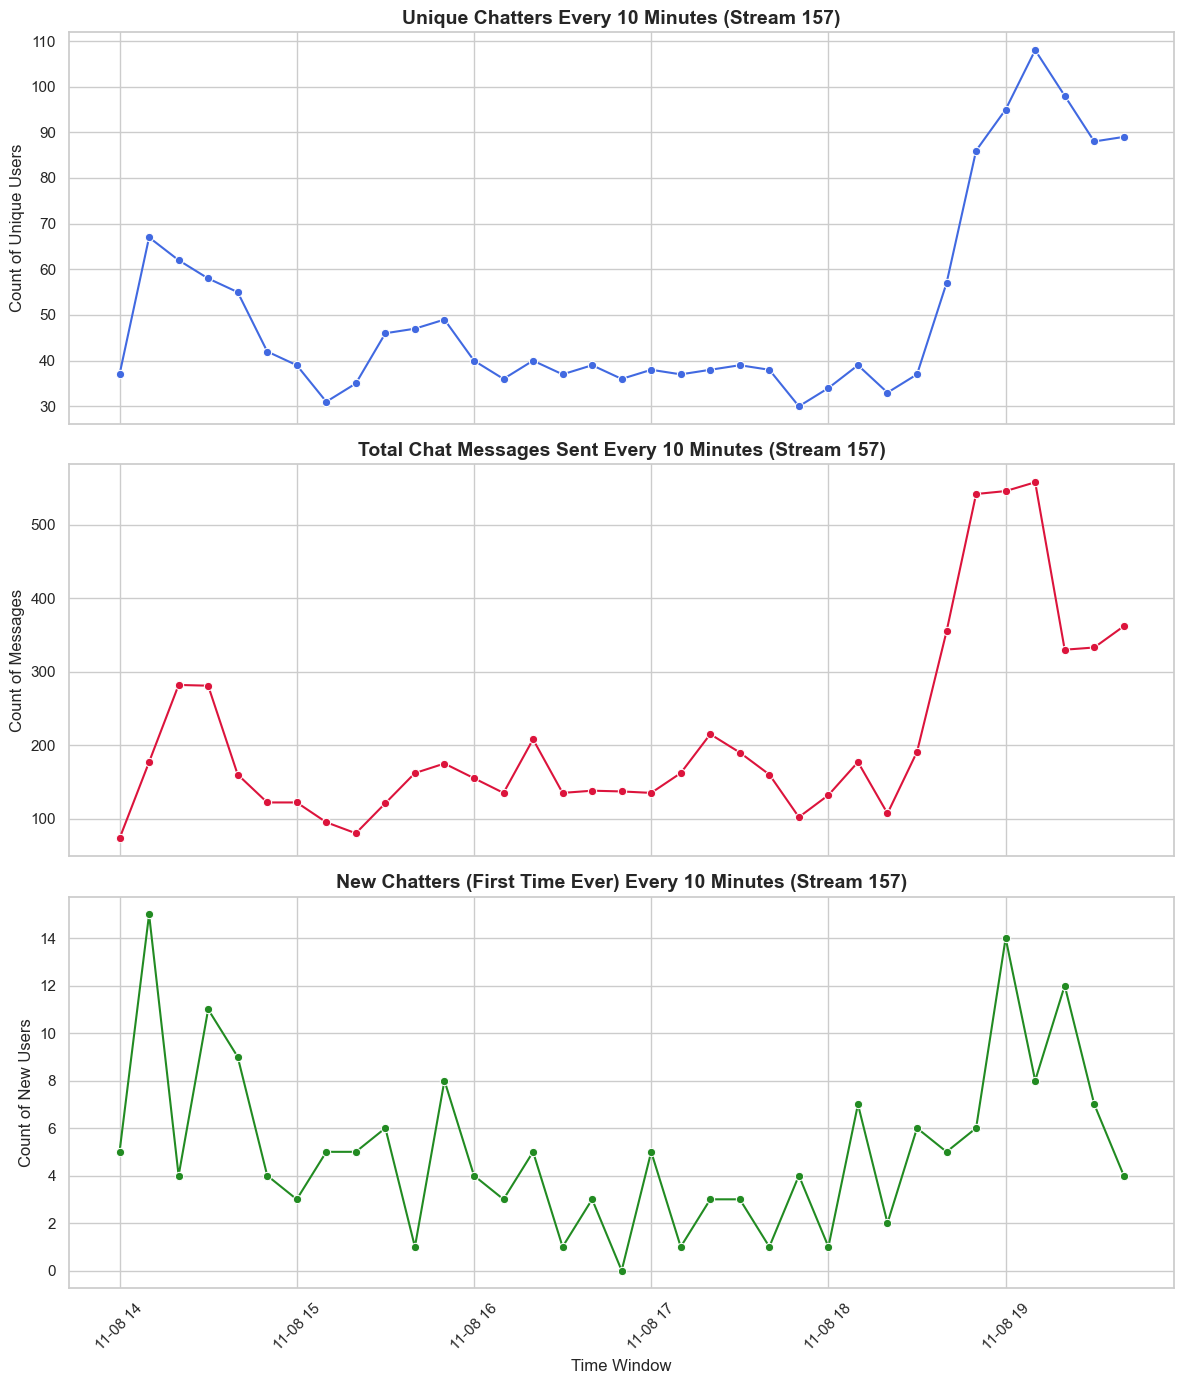

In [ ]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 157
started_on_157 = first_stream_per_user[first_stream_per_user == 157].index

# Filter total unique streams to ONLY include those who started on 157
# We subtract 1 because we want "20 ANOTHER streams" (excluding 157)
target_users = total_unique_streams.loc[started_on_157]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 157 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 157 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 157
df_157 = data[data['stream'] == 157].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_157['is_new_chatter'] = df_157['user'].isin(started_on_157) & ~df_157['user'].duplicated()

# Set date as index for resampling
df_157.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_157 = df_157.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 157
# -------------------------------------------------------------------------

# 1. Filter for stream 157
df_raids = data[data['stream'] == 157].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 157:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 157 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_157, x=resampled_157.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 157)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_157, x=resampled_157.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 157)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_157, x=resampled_157.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 157)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Users who started on stream 158 and visited >= 20 other streams:
['LoupinStormborn', 'eccentric_bilb0', 'occean851', 'zReeZ_Angel']

No raids detected on Stream 158 using these criteria.


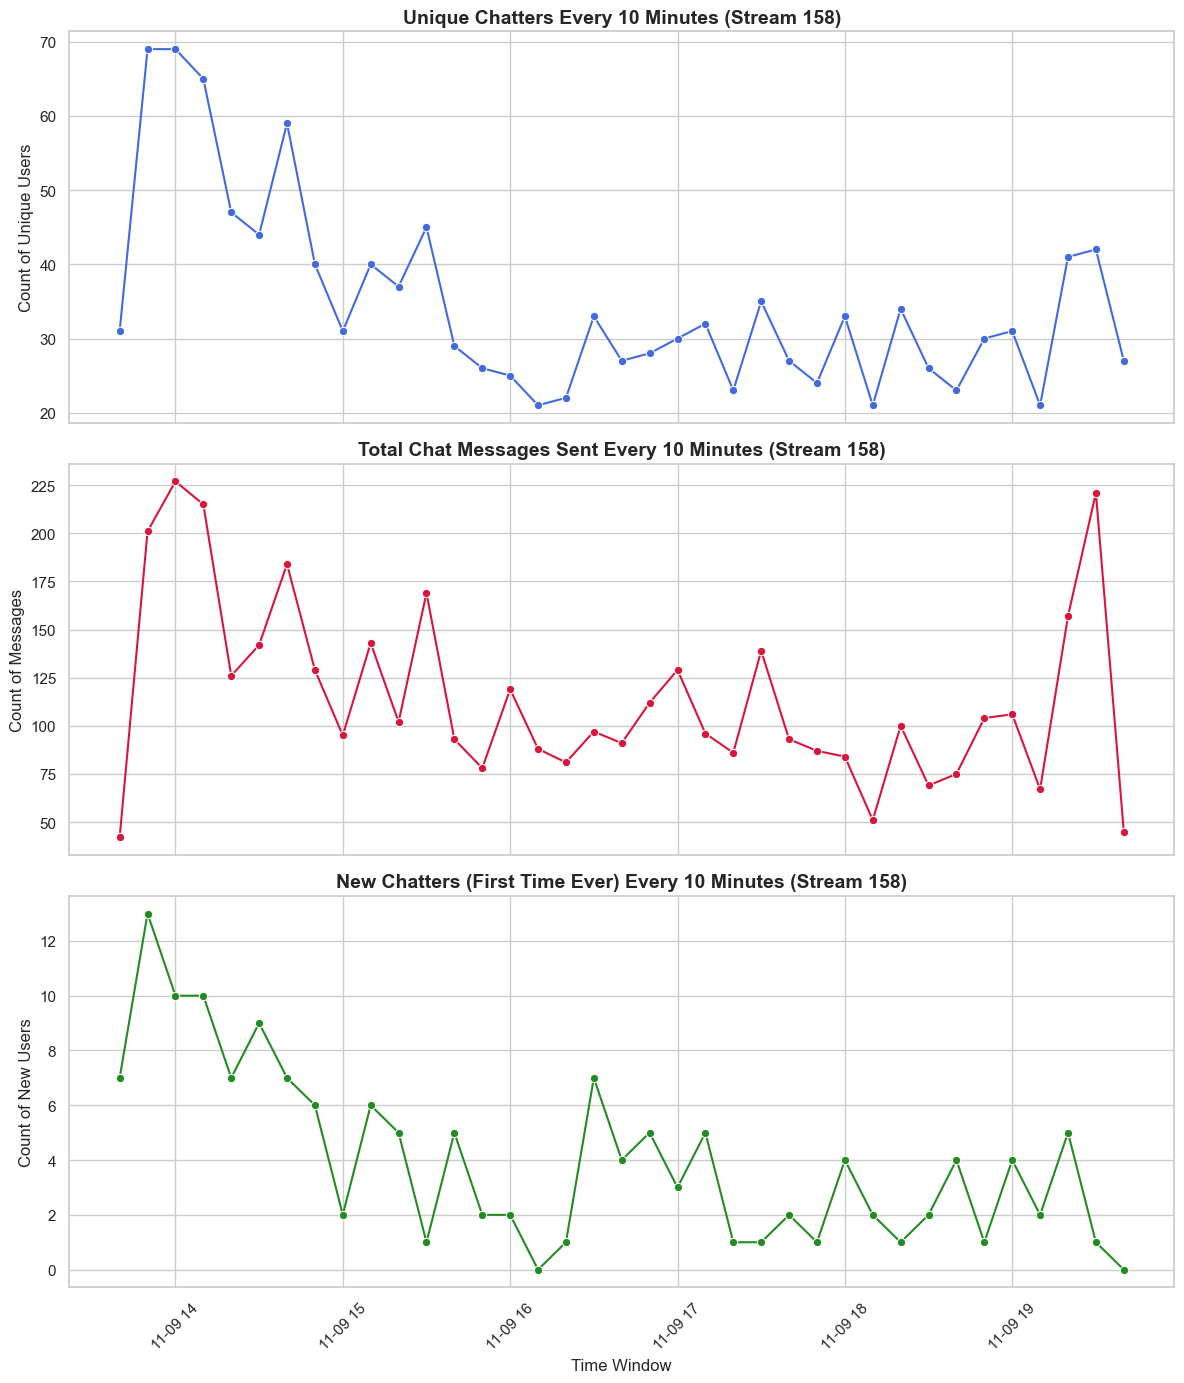

In [15]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 158
started_on_158 = first_stream_per_user[first_stream_per_user == 158].index

# Filter total unique streams to ONLY include those who started on 158
# We subtract 1 because we want "20 ANOTHER streams" (excluding 158)
target_users = total_unique_streams.loc[started_on_158]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 158 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 158 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 158
df_158 = data[data['stream'] == 158].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_158['is_new_chatter'] = df_158['user'].isin(started_on_158) & ~df_158['user'].duplicated()

# Set date as index for resampling
df_158.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_158 = df_158.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 158
# -------------------------------------------------------------------------

# 1. Filter for stream 158
df_raids = data[data['stream'] == 158].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 158:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 158 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_158, x=resampled_158.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 158)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_158, x=resampled_158.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 158)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_158, x=resampled_158.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 158)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Users who started on stream 162 and visited >= 20 other streams:
['codymcg7', 'ikriiq']

Found 2 raid(s) on Stream 162:
                Raid Time    Raider  Viewer Count
2024-11-13 14:23:59+01:00   Exerpas           163
2024-11-13 16:24:02+01:00 SaiVoL_TV           232


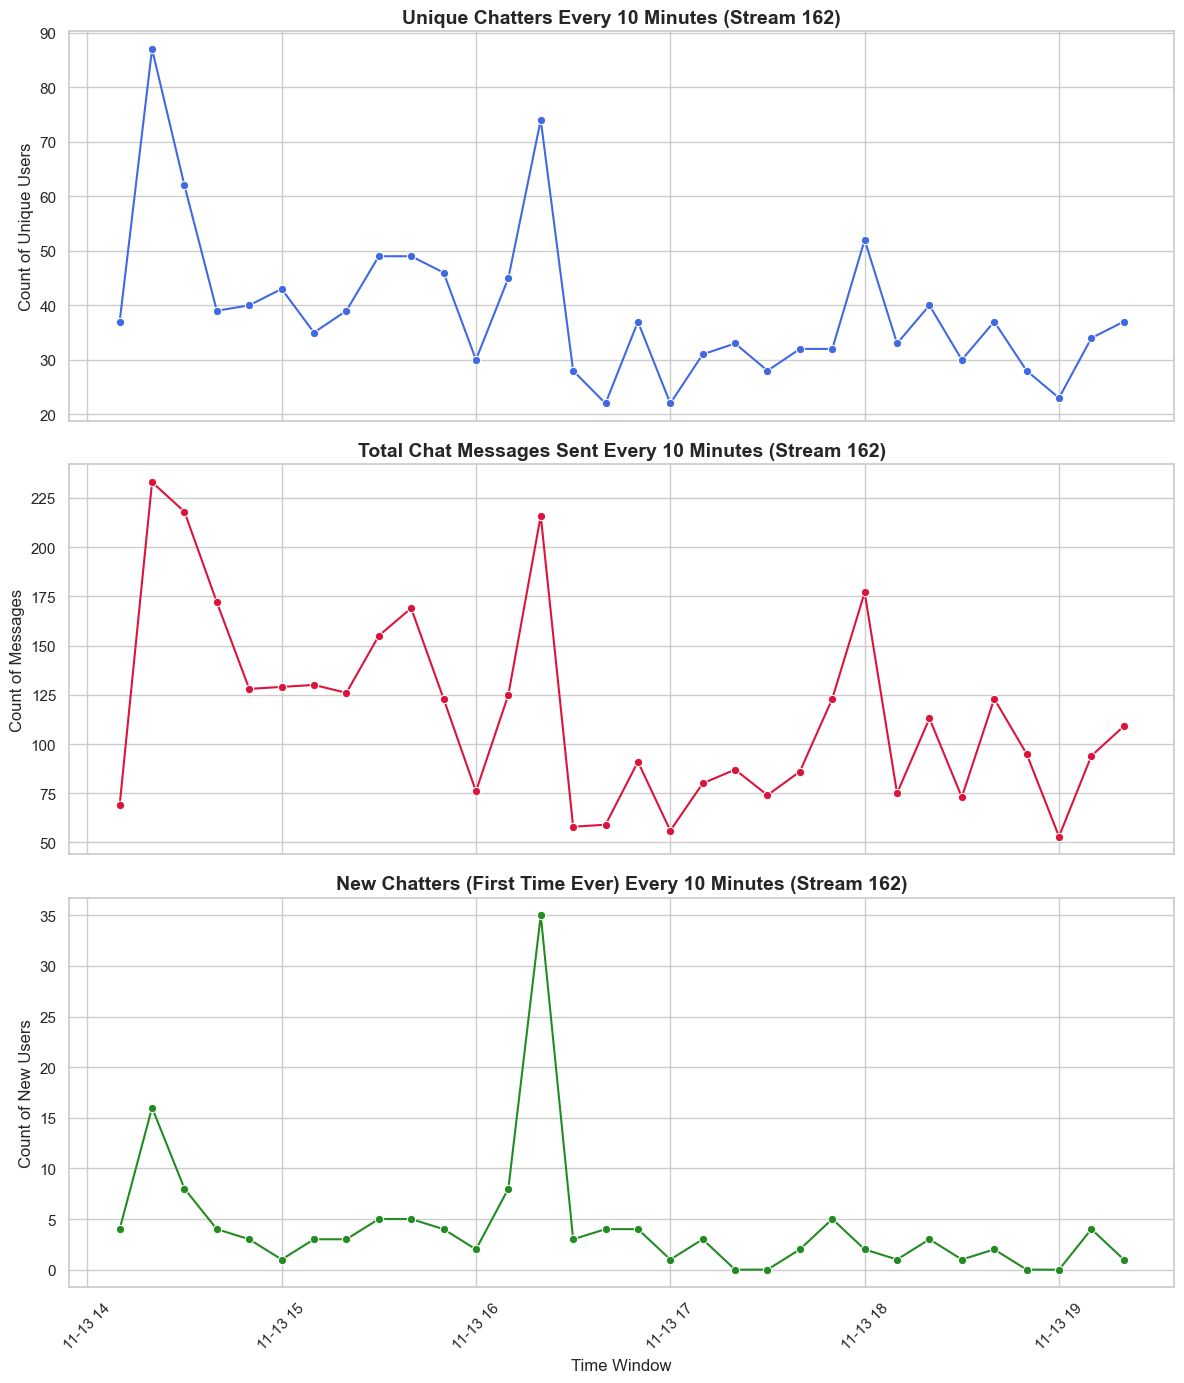

In [16]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 162
started_on_162 = first_stream_per_user[first_stream_per_user == 162].index

# Filter total unique streams to ONLY include those who started on 162
# We subtract 1 because we want "20 ANOTHER streams" (excluding 162)
target_users = total_unique_streams.loc[started_on_162]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 162 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 162 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 162
df_162 = data[data['stream'] == 162].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_162['is_new_chatter'] = df_162['user'].isin(started_on_162) & ~df_162['user'].duplicated()

# Set date as index for resampling
df_162.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_162 = df_162.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 162
# -------------------------------------------------------------------------

# 1. Filter for stream 162
df_raids = data[data['stream'] == 162].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 162:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 162 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_162, x=resampled_162.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 162)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_162, x=resampled_162.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 162)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_162, x=resampled_162.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 162)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Users who started on stream 163 and visited >= 20 other streams:
['BrAv0_6iX', 'S4SK__', 'VincentVonBroccoli', 'popkinso0n']

Found 1 raid(s) on Stream 163:
                Raid Time         Raider  Viewer Count
2024-11-14 15:30:31+01:00 dima_wallhacks          1109


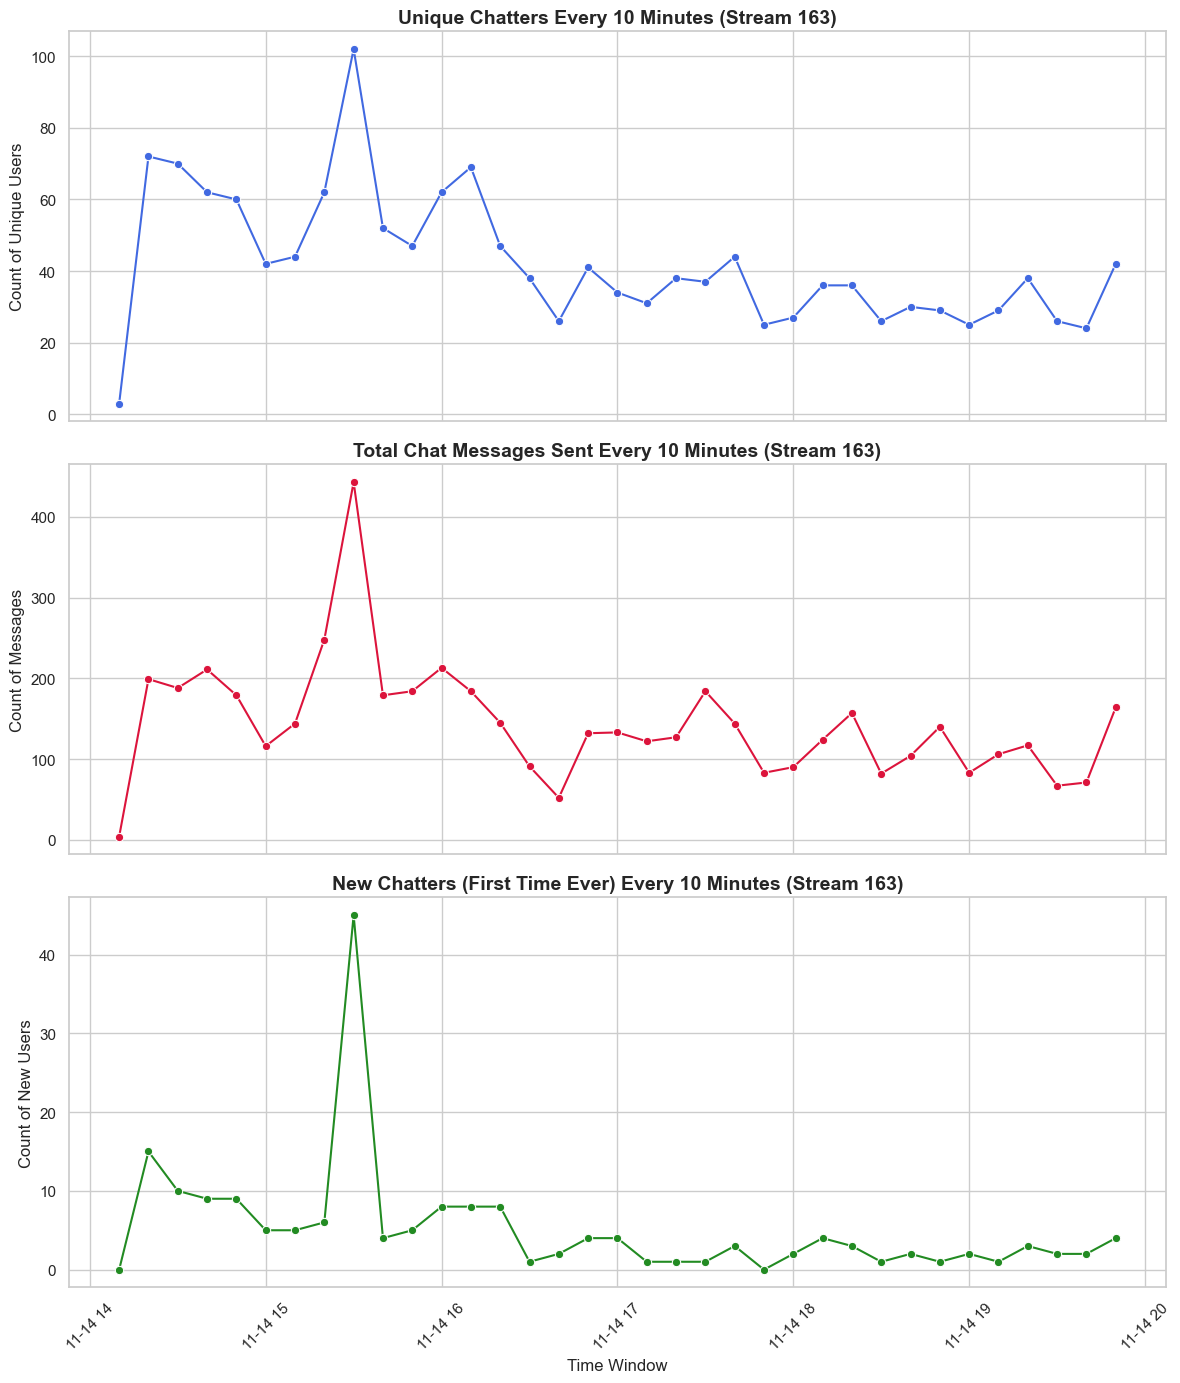

In [17]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 163
started_on_163 = first_stream_per_user[first_stream_per_user == 163].index

# Filter total unique streams to ONLY include those who started on 163
# We subtract 1 because we want "20 ANOTHER streams" (excluding 163)
target_users = total_unique_streams.loc[started_on_163]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 163 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 163 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 163
df_163 = data[data['stream'] == 163].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_163['is_new_chatter'] = df_163['user'].isin(started_on_163) & ~df_163['user'].duplicated()

# Set date as index for resampling
df_163.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_163 = df_163.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 163
# -------------------------------------------------------------------------

# 1. Filter for stream 163
df_raids = data[data['stream'] == 163].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 163:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 163 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_163, x=resampled_163.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 163)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_163, x=resampled_163.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 163)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_163, x=resampled_163.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 163)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Users who started on stream 164 and visited >= 20 other streams:
['Brods', 'berthamilk', 'portgas_d_ace3']

No raids detected on Stream 164 using these criteria.


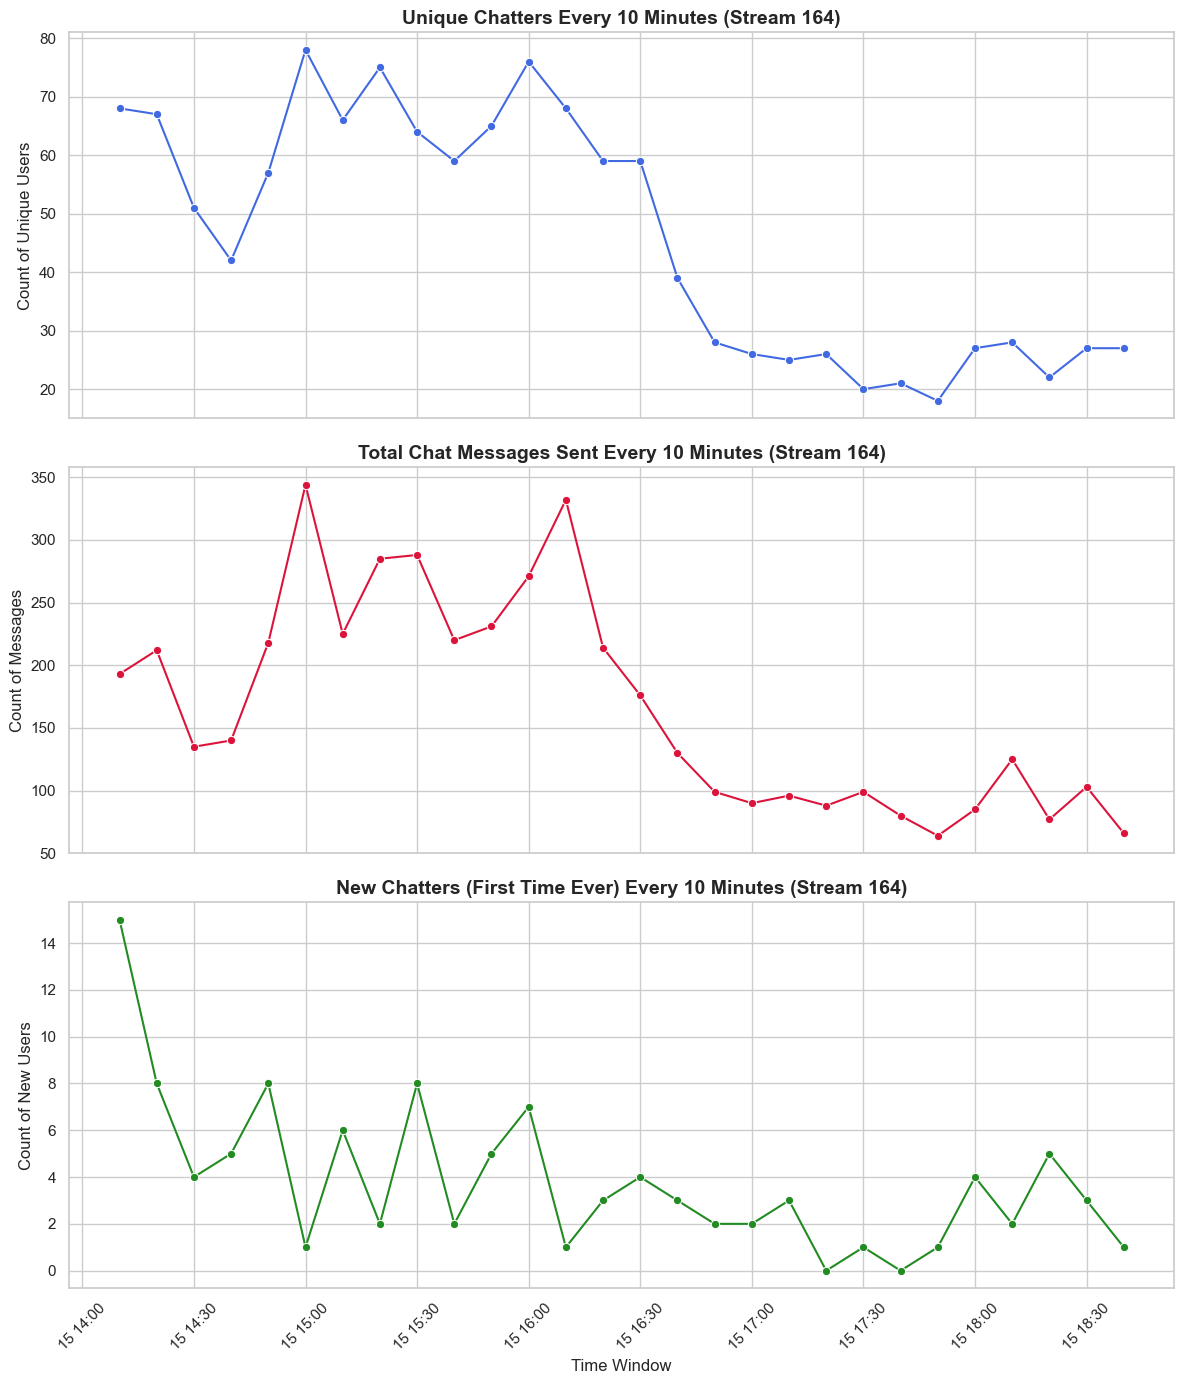

In [18]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 164
started_on_164 = first_stream_per_user[first_stream_per_user == 164].index

# Filter total unique streams to ONLY include those who started on 164
# We subtract 1 because we want "20 ANOTHER streams" (excluding 164)
target_users = total_unique_streams.loc[started_on_164]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 164 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 164 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 164
df_164 = data[data['stream'] == 164].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_164['is_new_chatter'] = df_164['user'].isin(started_on_164) & ~df_164['user'].duplicated()

# Set date as index for resampling
df_164.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_164 = df_164.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 164
# -------------------------------------------------------------------------

# 1. Filter for stream 164
df_raids = data[data['stream'] == 164].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 164:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 164 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_164, x=resampled_164.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 164)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_164, x=resampled_164.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 164)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_164, x=resampled_164.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 164)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Users who started on stream 165 and visited >= 20 other streams:
['blasi01_', 'goadjones', 'greekviewer1', 'mingqian2222', 'rashids77', 'uuccugr']

No raids detected on Stream 165 using these criteria.


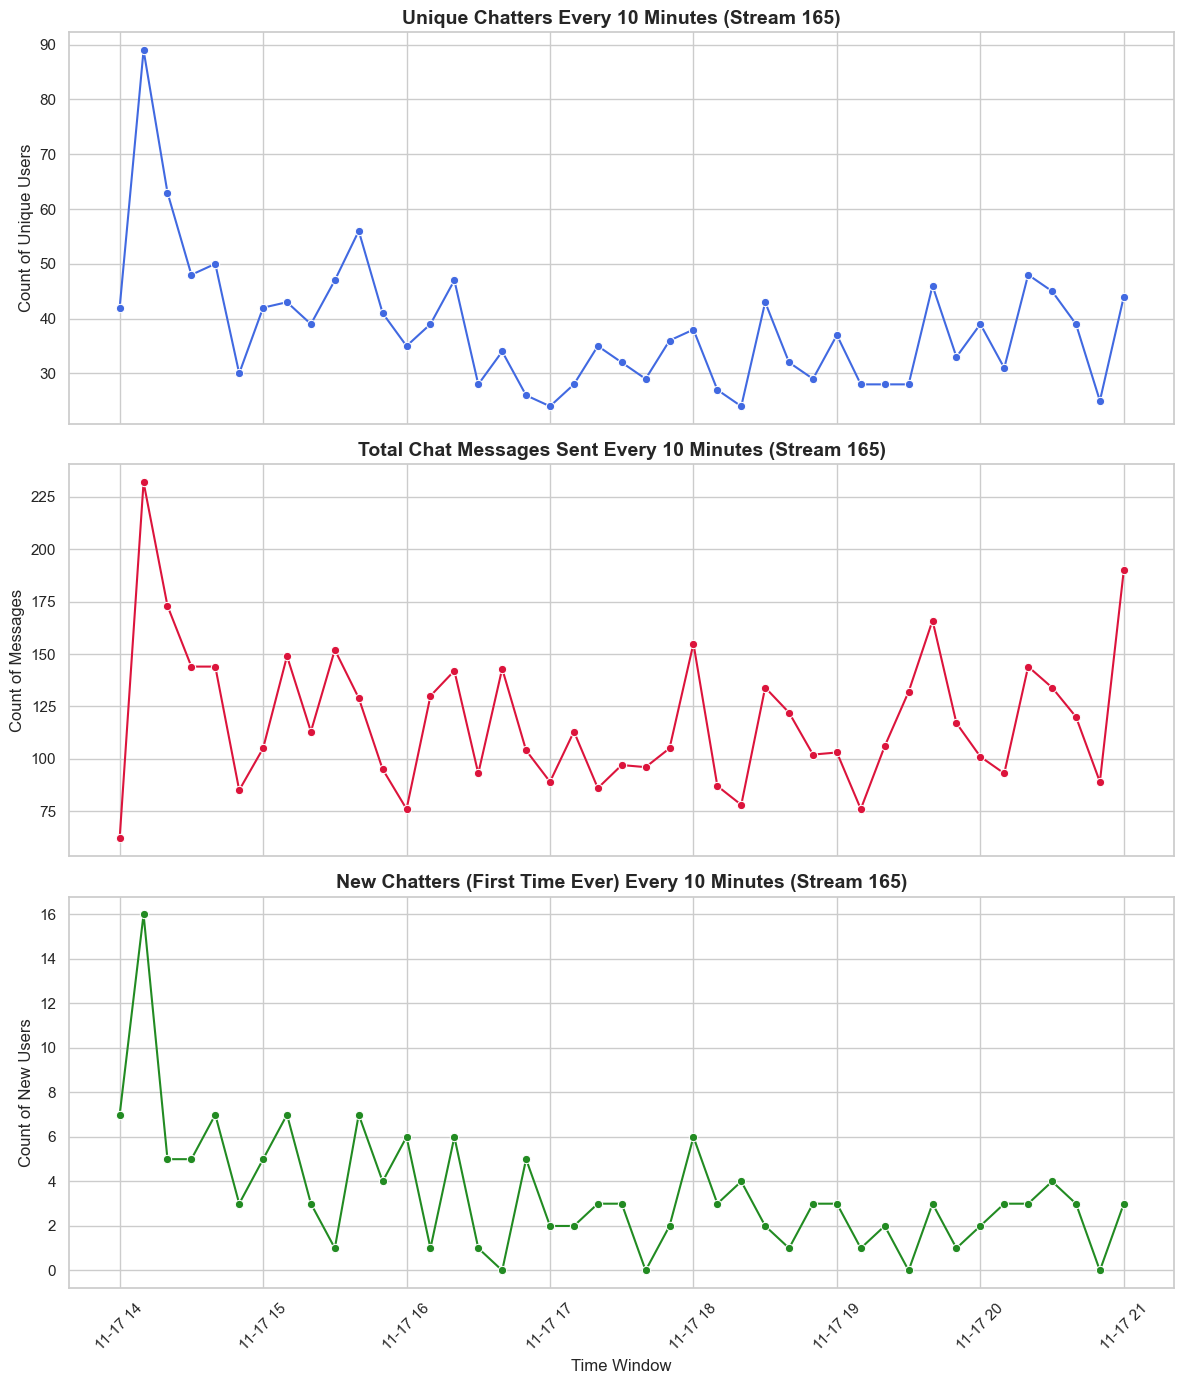

In [19]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 165
started_on_165 = first_stream_per_user[first_stream_per_user == 165].index

# Filter total unique streams to ONLY include those who started on 165
# We subtract 1 because we want "20 ANOTHER streams" (excluding 165)
target_users = total_unique_streams.loc[started_on_165]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 165 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 165 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 165
df_165 = data[data['stream'] == 165].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_165['is_new_chatter'] = df_165['user'].isin(started_on_165) & ~df_165['user'].duplicated()

# Set date as index for resampling
df_165.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_165 = df_165.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 165
# -------------------------------------------------------------------------

# 1. Filter for stream 165
df_raids = data[data['stream'] == 165].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 165:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 165 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_165, x=resampled_165.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 165)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_165, x=resampled_165.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 165)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_165, x=resampled_165.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 165)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Users who started on stream 166 and visited >= 20 other streams:
['Andrelele4', 'ad_complainer', 'barut_adem', 'eric_273', 'kamelski', 'lala2440']

Found 1 raid(s) on Stream 166:
                Raid Time        Raider  Viewer Count
2024-11-18 19:56:40+01:00 speedyemperor            21


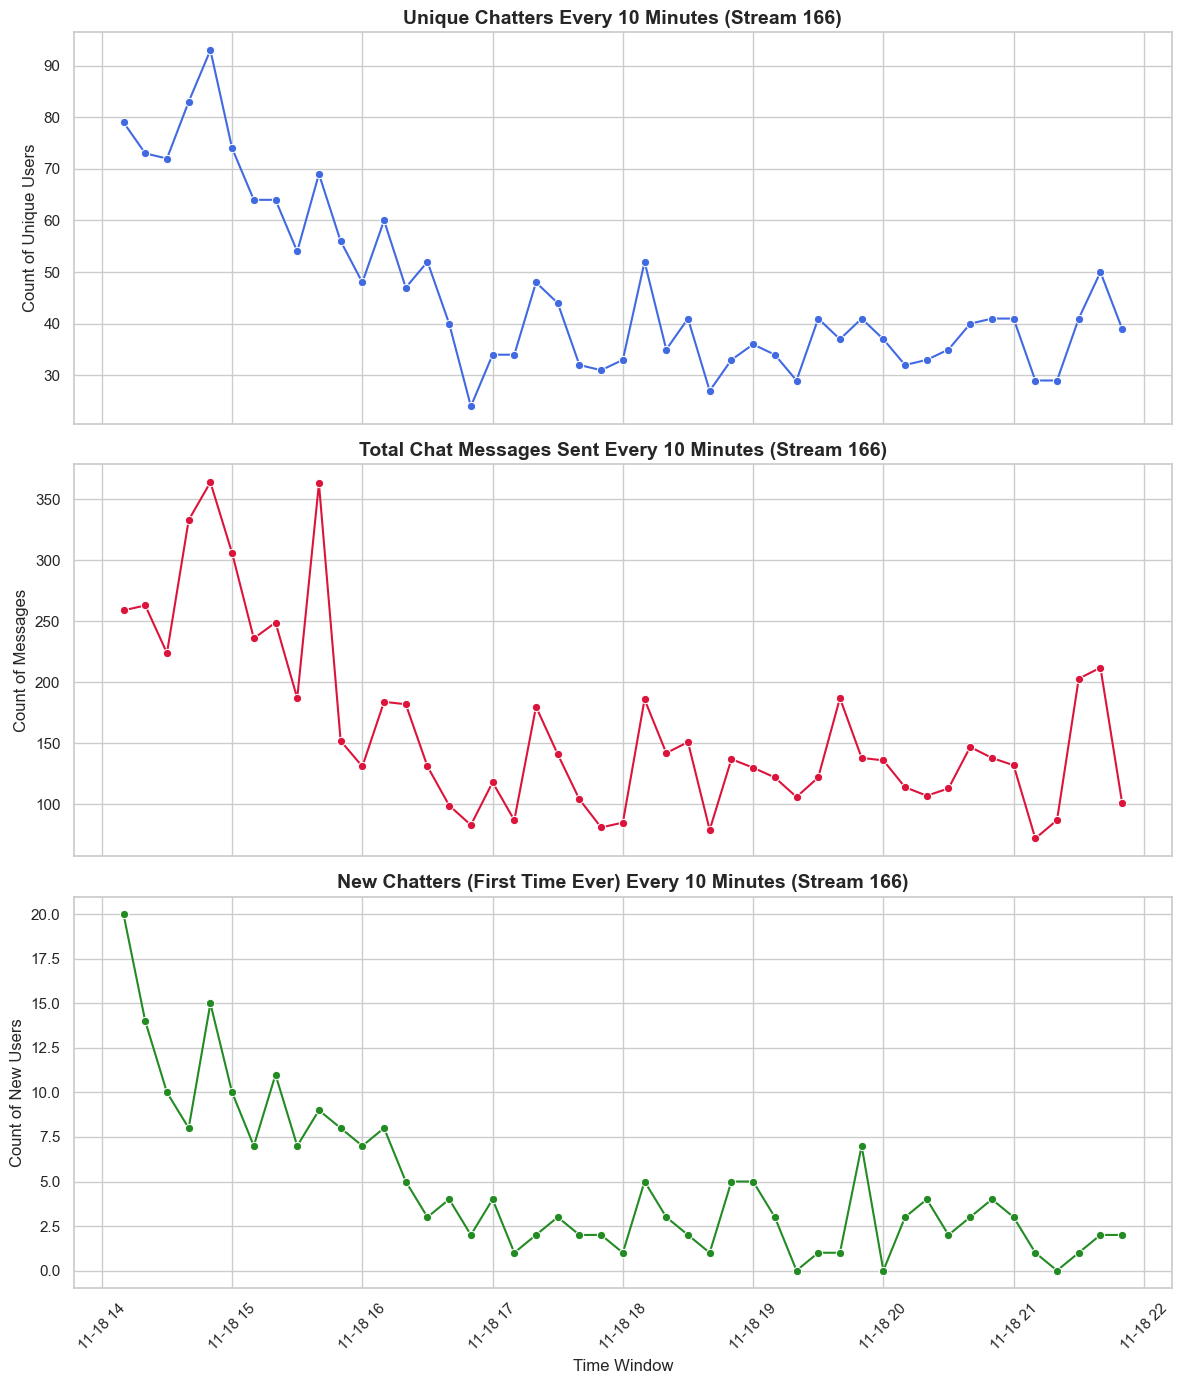

In [20]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 166
started_on_166 = first_stream_per_user[first_stream_per_user == 166].index

# Filter total unique streams to ONLY include those who started on 166
# We subtract 1 because we want "20 ANOTHER streams" (excluding 166)
target_users = total_unique_streams.loc[started_on_166]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 166 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 166 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 166
df_166 = data[data['stream'] == 166].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_166['is_new_chatter'] = df_166['user'].isin(started_on_166) & ~df_166['user'].duplicated()

# Set date as index for resampling
df_166.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_166 = df_166.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 166
# -------------------------------------------------------------------------

# 1. Filter for stream 166
df_raids = data[data['stream'] == 166].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 166:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 166 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_166, x=resampled_166.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 166)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_166, x=resampled_166.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 166)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_166, x=resampled_166.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 166)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

last stream 662

Users who started on stream 632 and visited >= 20 other streams:
[]

Found 1 raid(s) on Stream 632:
                Raid Time     Raider  Viewer Count
2026-05-18 16:59:15+02:00 MaicuGames            16


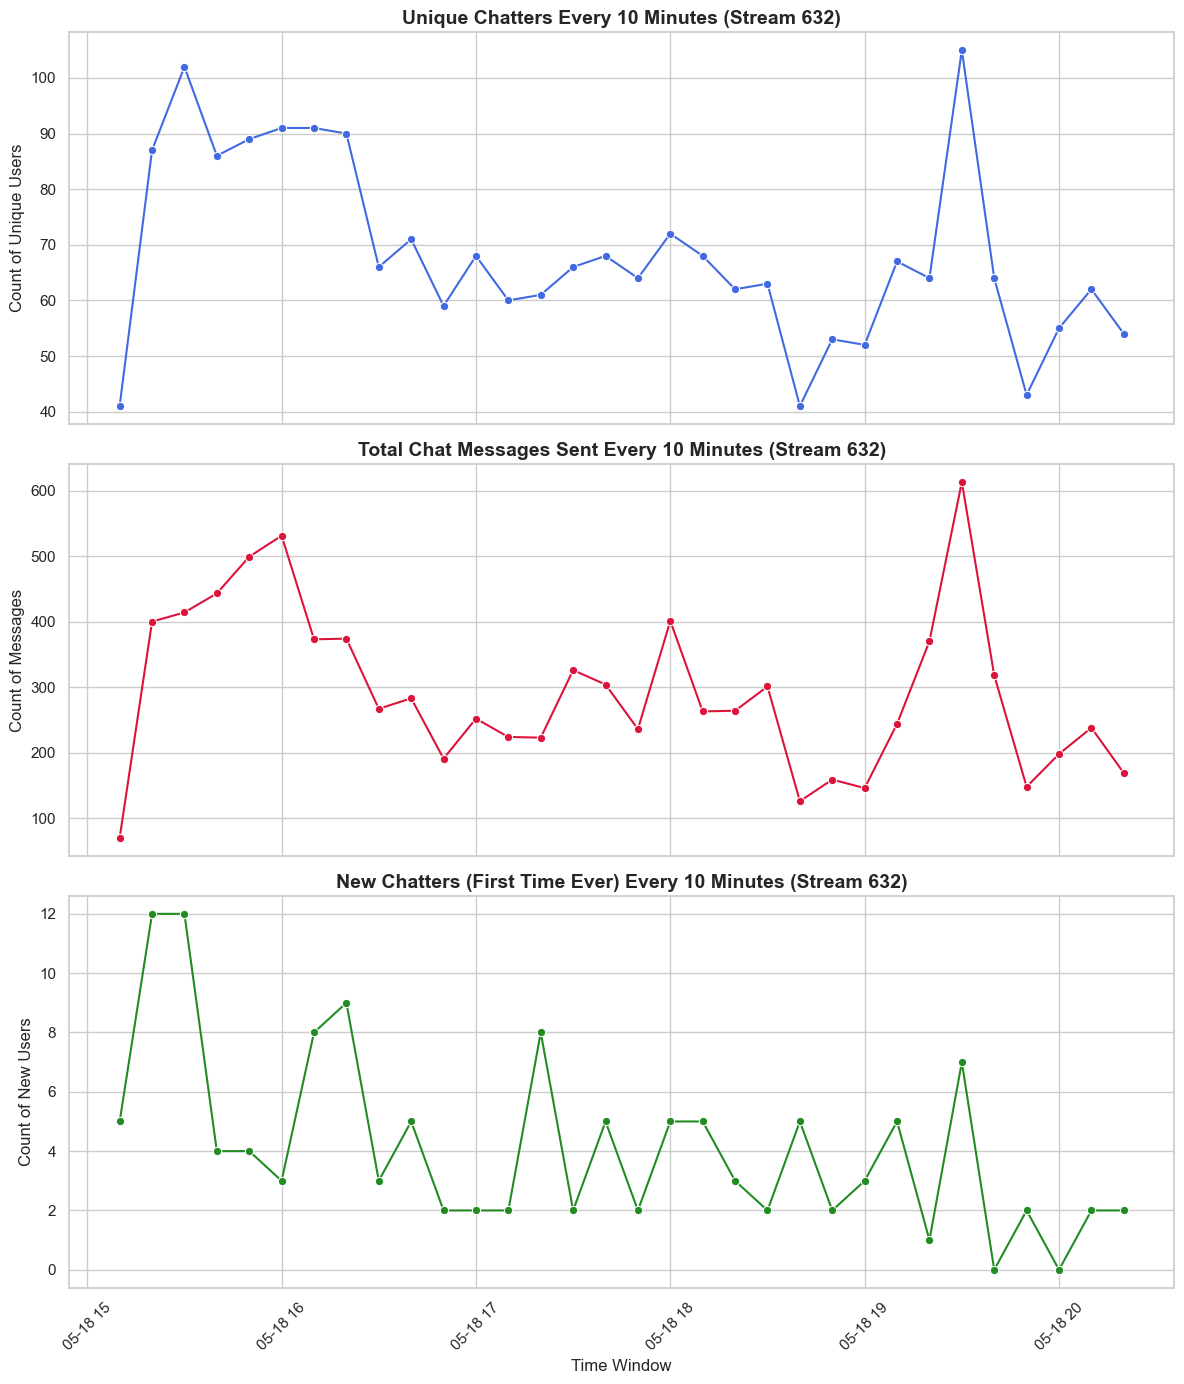

In [27]:
# -------------------------------------------------------------------------
# 0. Global Analysis (First-timers & Stream hoppers)
# -------------------------------------------------------------------------

# Users whose VERY FIRST stream was 632
started_on_632 = first_stream_per_user[first_stream_per_user == 632].index

# Filter total unique streams to ONLY include those who started on 632
# We subtract 1 because we want "20 ANOTHER streams" (excluding 632)
target_users = total_unique_streams.loc[started_on_632]
target_users = target_users[target_users - 1 >= 20].index.tolist()

print(f"Users who started on stream 632 and visited >= 20 other streams:\n{target_users}\n")

# -------------------------------------------------------------------------
# 1. Prepare Data for Stream 632 Time-Series
# -------------------------------------------------------------------------

# Filter for stream 632
df_632 = data[data['stream'] == 632].copy()

# Add a boolean column indicating if this message was the user's first time EVER chatting
df_632['is_new_chatter'] = df_632['user'].isin(started_on_632) & ~df_632['user'].duplicated()

# Set date as index for resampling
df_632.set_index('date', inplace=True)

# Resample every 10 minutes
# - Unique Chatters: count unique users in that window
# - Total Messages: count number of rows (messages)
# - New Chatters: sum the boolean flags (True = 1)
resampled_632 = df_632.resample('10min').agg(
    unique_chatters=('user', 'nunique'),
    total_messages=('message', 'count'),
    new_chatters=('is_new_chatter', 'sum')
)

# -------------------------------------------------------------------------
# 1.5 Raid Data for Stream 632
# -------------------------------------------------------------------------

# 1. Filter for stream 632
df_raids = data[data['stream'] == 632].copy()

# 2. Check if the username is inside the message
# (Case-insensitive comparison to avoid missing matches due to capitalization)
user_in_msg = df_raids.apply(lambda row: str(row['user']).lower() in str(row['message']).lower(), axis=1)

# 3. Check if ' raiders from ' is in the message
has_raiders_text = df_raids['message'].str.contains(' raiders from ', case=False, na=False)

# Combine the filters
potential_raids = df_raids[user_in_msg & has_raiders_text].copy()

# 4. Extract the viewer count (digits at the start of the message)
# Regex \d+ looks for one or more digits at the beginning (^) of the string
potential_raids['viewers'] = potential_raids['message'].str.extract(r'^(\d+)')

# Drop rows where the message didn't actually start with a number
raids = potential_raids.dropna(subset=['viewers']).copy()
raids['viewers'] = raids['viewers'].astype(int)

# 5. Select and rename columns for a clean output
raid_summary = raids.reset_index()[['date', 'user', 'viewers']].rename(
    columns={'date': 'Raid Time', 'user': 'Raider', 'viewers': 'Viewer Count'}
)

# Print results
if not raid_summary.empty:
    print(f"Found {len(raid_summary)} raid(s) on Stream 632:")
    print(raid_summary.to_string(index=False))
else:
    print("No raids detected on Stream 632 using these criteria.")

# -------------------------------------------------------------------------
# 2. Plotting the Graphs
# -------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Graph 1: Unique Chatters
sns.lineplot(data=resampled_632, x=resampled_632.index, y='unique_chatters', ax=axes[0], color='royalblue', marker='o')
axes[0].set_title('Unique Chatters Every 10 Minutes (Stream 632)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count of Unique Users')

# Graph 2: Total Chat Messages
sns.lineplot(data=resampled_632, x=resampled_632.index, y='total_messages', ax=axes[1], color='crimson', marker='o')
axes[1].set_title('Total Chat Messages Sent Every 10 Minutes (Stream 632)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count of Messages')

# Graph 3: New Chatters (Swapped from barplot to lineplot to fix timezone error)
sns.lineplot(data=resampled_632, x=resampled_632.index, y='new_chatters', ax=axes[2], color='forestgreen', marker='o')
axes[2].set_title('New Chatters (First Time Ever) Every 10 Minutes (Stream 632)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Count of New Users')
axes[2].set_xlabel('Time Window')

# Clean up X-axis formatting for timestamps
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()